In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
while not os.path.isdir('.git'):
    os.chdir('..')

# Plot parameters
import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"
mpl.rcParams["axes.labelsize"] = 9
mpl.rcParams["xtick.labelsize"] = 9
mpl.rcParams["ytick.labelsize"] = 9
mpl.rcParams["legend.fontsize"] = 9
mpl.rcParams["axes.titlesize"] = 9

# 9000 Hz carrier with varying TI strength

In [2]:
def expand_time(original, max_time = 10_000, time_step = 0.025):
    original["Time"] = (original["Time"] / time_step).round() * time_step
    original = original.sort_values("Time")

    new_time = np.arange(0, max_time + time_step, time_step)

    expanded = pd.DataFrame({ "Time": new_time })
    expanded = pd.merge_asof(expanded, original, on = "Time", direction = "backward")

    return expanded

In [3]:
project = "temporal-interference-1"
frequency = 10
idxs = np.arange(0, 20)
intensities = np.arange(0.2, 1, 0.1)

In [4]:
conditions = {}

conditions["No TI"] = [ f"output/{project}/{idx}/random_poisson/{frequency}/noTI_0.1/synapse_weights.csv" for idx in idxs ]
conditions["1k 90%"] = [ f"output/{project}/{idx}/random_poisson/{frequency}/1000_130_0.9_0.1/synapse_weights.csv" for idx in idxs ]

for intensity in intensities:
    conditions[ f"{int(intensity * 100)}%" ] = [ f"output/{project}/{idx}/random_poisson/{frequency}/9000_130_{round(intensity, 2)}_0.1/synapse_weights.csv" for idx in idxs ]

In [5]:
def readConditions(conditions):
    averages = {}
    errors = {}
    time = []

    for (condition, files) in conditions.items():
        print(f"Processing {condition}")

        weights = []
        for file in files:
            synapse_weights = pd.read_csv(file, index_col = 0)
            synapse_weights = expand_time(synapse_weights, time_step = 0.0025)
            time = synapse_weights.Time.to_list()

            synapse_weights = np.array([ synapse_weights[f"Synapse{i}"] for i in range(0, 10) ])
            weights.append(synapse_weights)

        weights = np.array(weights)
        weights = weights.reshape((weights.shape[0] * weights.shape[1], weights.shape[2]))

        averages[condition] = weights.mean(axis = 0)
        errors[condition] = weights.std(axis = 0) / np.sqrt(weights.shape[0])

    return averages, errors, time

averages, errors, time = readConditions(conditions)

Processing No TI
Processing 1k 90%
Processing 20%
Processing 30%
Processing 40%
Processing 50%
Processing 60%
Processing 70%
Processing 80%
Processing 90%


In [6]:
strength1k = pd.read_csv(f"output/{project}/variable-time-ef/90_90_1000.csv")
amplitude1k = strength1k[ strength1k.Beat == 130 ]["SubthresholdAmplitude"].tolist()[0]
actualValue1k = round(amplitude1k * 0.9)

strength9k = pd.read_csv(f"output/{project}/variable-time-ef/90_90_9000.csv")
amplitude9k = strength9k[ strength1k.Beat == 130 ]["SubthresholdAmplitude"].tolist()[0]

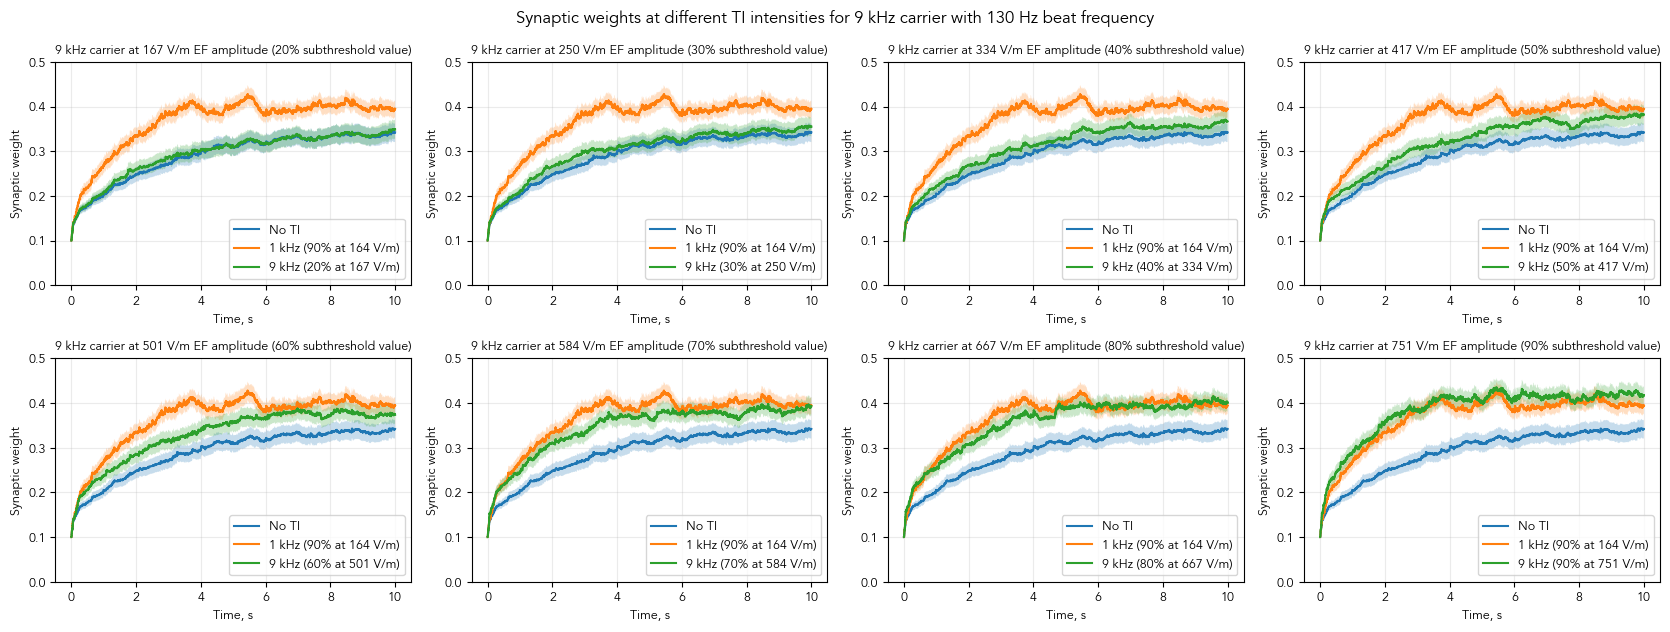

In [7]:
fig, axs = plt.subplots(nrows = 2, ncols = 4, figsize = (8.4 * 2, 6.4))
axs = axs.flatten()

noTI = "No TI"
carrier_1k = "1k 90%"
time_s = np.array(time) / 1000
for (ax, intensity) in zip(axs, intensities):
    condition = f"{int(intensity * 100)}%"
    actualValue = round(intensity * amplitude9k)

    # Show no TI result
    ax.plot(
        time_s,
        averages[noTI],
        label = noTI
    )

    ax.fill_between(
        time_s, averages[noTI] - errors[noTI], averages[noTI] + errors[noTI],
        alpha = 0.25,
        edgecolor = None
    )

    # Show 1 kHz carrier results
    ax.plot(
        time_s,
        averages[carrier_1k],
        label = f"1 kHz (90% at {actualValue1k} V/m)"
    )

    ax.fill_between(
        time_s, averages[carrier_1k] - errors[carrier_1k], averages[carrier_1k] + errors[carrier_1k],
        alpha = 0.25,
        edgecolor = None
    )

    # Show 9 kHz carrier with different intensity levels
    ax.plot(
        time_s,
        averages[condition],
        label = f"9 kHz ({condition} at {actualValue} V/m)"
    )

    ax.fill_between(
        time_s, averages[condition] - errors[condition], averages[condition] + errors[condition],
        alpha = 0.25,
        edgecolor = None
    )

    ax.legend(loc = "lower right")
    ax.set_xlabel("Time, s")
    ax.set_ylabel("Synaptic weight")
    ax.set_ylim(0, 0.5)
    ax.set_title(f"9 kHz carrier at {actualValue} V/m EF amplitude ({condition} subthreshold value)")
    ax.grid(alpha = 0.25)

plt.suptitle("Synaptic weights at different TI intensities for 9 kHz carrier with 130 Hz beat frequency")

fig.tight_layout()

plt.show()

## Firing rate

It is clear that the TI amplitude for the initial 1000 Hz stimulation (90% of the subthreshold value) might be too strong - or, rather, not required to be so high to see the differences in the synaptic weight changes. Would be interesting to see, where the differences in action potential firing appears:

- What is the AP frequency at the 90% of the subthreshold amplitude? Is there significant difference between TI / no TI conditions?
- What is the AP frequency at lower amplitudes (40-50% subthreshold amplitude, where we start observing the differences between TI / no TI conditions)? Is there significant difference between TI / no TI conditions?
- Is AP firing required to see changes in synaptic plasticity? (If so, the model might be incomplete)

In [ ]:
conditions = {}

conditions["No TI"] = [ f"output/{project}/{idx}/random_poisson/{frequency}/noTI_0.1/synapse_weights.csv" for idx in idxs ]
conditions["1k 90%"] = [ f"output/{project}/{idx}/random_poisson/{frequency}/1000_130_0.9_0.1/synapse_weights.csv" for idx in idxs ]

for intensity in intensities:
    conditions[ f"{int(intensity * 100)}%" ] = [ f"output/{project}/{idx}/random_poisson/{frequency}/9000_130_{round(intensity, 2)}_0.1/synapse_weights.csv" for idx in idxs ]

In [26]:
voltage = pd.read_csv("output/temporal-interference-1/0/random_poisson/10/noTI_0.1/voltage.csv", index_col=0)
voltage9k = pd.read_csv("output/temporal-interference-1/0/random_poisson/10/9000_130_0.2_0.1/voltage.csv", index_col=0)
voltage9k_strong = pd.read_csv("output/temporal-interference-1/0/random_poisson/10/9000_130_0.4_0.1/voltage.csv", index_col=0)

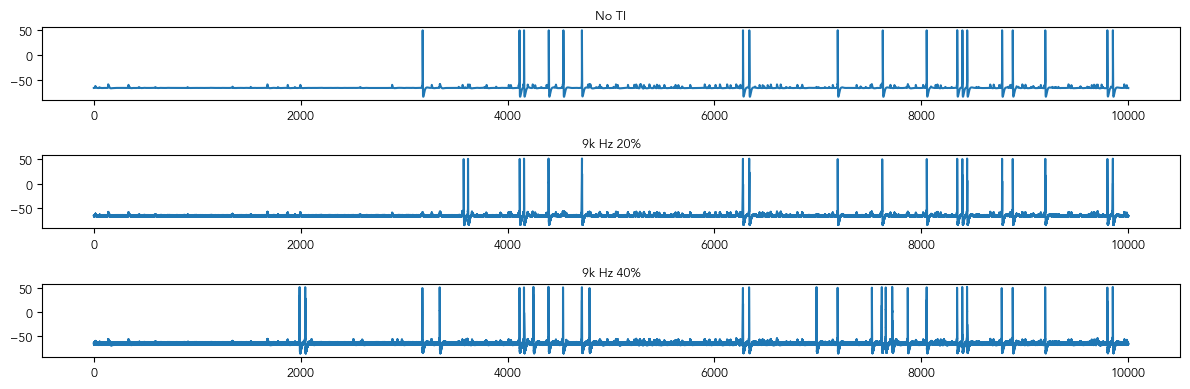

In [61]:
fig, axs = plt.subplots(nrows = 3, ncols = 1, figsize = (12, 4))

axs[0].plot(voltage.Time, voltage.Voltage, label = "No TI")
axs[0].set_title("No TI")

axs[1].plot(voltage9k.Time, voltage9k.Voltage, label = "9K 20%")
axs[1].set_title("9k Hz 20%")

axs[2].plot(voltage9k_strong.Time, voltage9k_strong.Voltage, label = "9K 40%")
axs[2].set_title("9k Hz 40%")

fig.tight_layout()
plt.show()


In [ ]:
import subprocess

In [36]:
freq_files = {}

freq_files["No TI"] = [ f"output/{project}/{idx}/random_poisson/{frequency}/noTI_0.1/spike_frequency.csv" for idx in idxs ]
freq_files["1k 90%"] = [ f"output/{project}/{idx}/random_poisson/{frequency}/1000_130_0.9_0.1/spike_frequency.csv" for idx in idxs ]

for intensity in intensities:
    freq_files[ f"{int(intensity * 100)}%" ] = [ f"output/{project}/{idx}/random_poisson/{frequency}/9000_130_{round(intensity, 2)}_0.1/spike_frequency.csv" for idx in idxs ]

In [51]:
results = []
for condition, files in freq_files.items():
    frequencies = []
    for file in files:
        n_lines = int(subprocess.check_output(["wc", "-l", file]).split()[0])
        frequencies.append(n_lines / 10)
    
    results.append(
        pd.DataFrame({
            condition: frequencies
        })
    )

results = pd.concat(results, axis = 1)

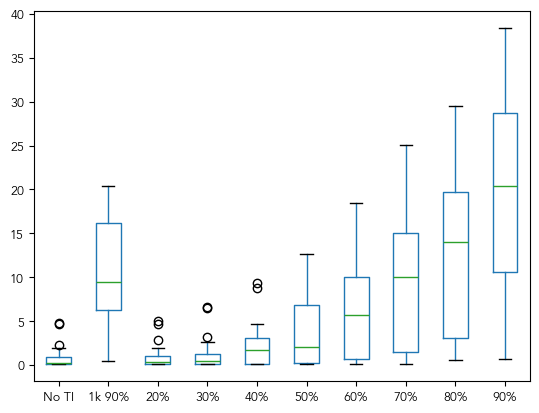

In [53]:
results.boxplot()
plt.grid(False)

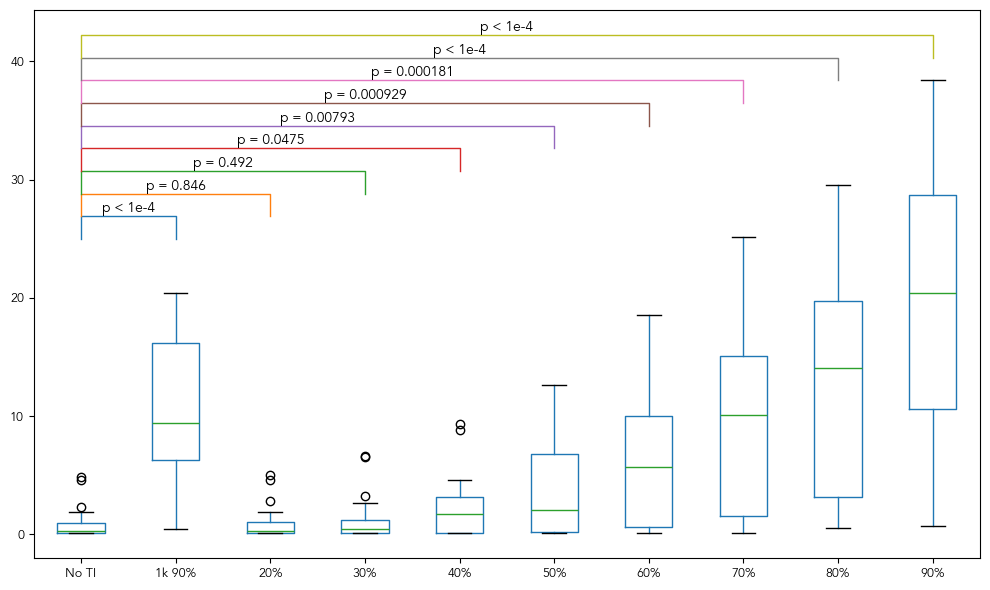

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# boxplot
ax = results.boxplot(figsize=(10, 6), grid=False)

# pairwise t-tests vs reference column
ref_col = "No TI"
ref = results[ref_col].dropna()

y_max = results.max().max()
h = y_max * 0.05

for i, col in enumerate(results.columns):
    if col == ref_col:
        continue

    data = results[col].dropna()
    if len(data) == 0:
        continue

    stat, p = ttest_ind(ref, data, equal_var=False)
    
    if p < 1e-4: label = "p < 1e-4"
    else: label = f"p = {p:.3g}"

    x1, x2 = 1, i + 1
    y = y_max + h * i - 0.4 * y_max

    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1)
    ax.text((x1 + x2) / 2, y + h, label, ha="center", va="bottom")

plt.tight_layout()
plt.show()